In [ ]:
# Integrating multi-omics features for breast cancer classification
# TCGA-BRCA Dataset from Kaggle
# Jessica Vu, Zahin Peerzade
# 09615 

In [7]:
import pandas as pd

df = pd.read_csv("data/brca_data_w_subtypes.csv")
print(df.shape)
print(df.columns[:10])
df.head()


(705, 1941)
Index(['rs_CLEC3A', 'rs_CPB1', 'rs_SCGB2A2', 'rs_SCGB1D2', 'rs_TFF1',
       'rs_MUCL1', 'rs_GSTM1', 'rs_PIP', 'rs_ADIPOQ', 'rs_ADH1B'],
      dtype='object')


,rs_CLEC3A,rs_CPB1,rs_SCGB2A2,rs_SCGB1D2,rs_TFF1,rs_MUCL1,rs_GSTM1,rs_PIP,rs_ADIPOQ,rs_ADH1B,...,pp_p62.LCK.ligand,pp_p70S6K,pp_p70S6K.pT389,pp_p90RSK,pp_p90RSK.pT359.S363,vital.status,PR.Status,ER.Status,HER2.Final.Status,histological.type
0,0.892818,6.580103,14.123672,10.606501,13.189237,6.649466,10.520335,10.338490,10.248379,10.229970,...,-0.691766,-0.337863,-0.178503,0.011638,-0.207257,0,Positive,Positive,Negative,infiltrating ductal carcinoma
1,0.000000,3.691311,17.116090,15.517231,9.867616,9.691667,8.179522,7.911723,1.289598,1.818891,...,0.279067,0.292925,-0.155242,-0.089365,0.267530,0,Positive,Negative,Negative,infiltrating ductal carcinoma
2,3.748150,4.375255,9.658123,5.326983,12.109539,11.644307,10.517330,5.114925,11.975349,11.911437,...,0.219910,0.308110,-0.190794,-0.222150,-0.198518,0,Positive,Positive,Negative,infiltrating ductal carcinoma
3,0.000000,18.235519,18.535480,14.533584,14.078992,8.913760,10.557465,13.304434,8.205059,9.211476,...,-0.266554,-0.079871,-0.463237,0.522998,-0.046902,0,Positive,Positive,Negative,infiltrating ductal carcinoma
4,0.000000,4.583724,15.711865,12.804521,8.881669,8.430028,12.964607,6.806517,4.294341,5.385714,...,-0.441542,-0.152317,0.511386,-0.096482,0.037473,0,Positive,Positive,Negative,infiltrating ductal carcinoma


In [8]:
non_numeric = df.select_dtypes(include='object').columns
print("Non-numeric columns:")
print(non_numeric)


Non-numeric columns:
Index(['PR.Status', 'ER.Status', 'HER2.Final.Status', 'histological.type'], dtype='object')


In [9]:
print(df['ER.Status'].value_counts())


ER.Status
Positive                       414
Negative                       135
Not Performed                   27
Performed but Not Available      5
Indeterminate                    2
Name: count, dtype: int64


In [10]:
import numpy as np

# Filtering to only Positive/Negative ER status
df_clean = df[df['ER.Status'].isin(['Positive', 'Negative'])].copy()

# Dropping other metadata columns 
df_clean = df_clean.drop(['PR.Status', 'HER2.Final.Status', 'histological.type'], axis=1)

# Splitting into features and labels
X = df_clean.drop('ER.Status', axis=1)
y = np.where(df_clean['ER.Status'] == 'Positive', 1, 0)

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Positive samples:", y.sum())


X shape: (549, 1937)
y shape: (549,)
Positive samples: 414


In [11]:
from sklearn.preprocessing import StandardScaler

# Replacing any missing values with the median
X_filled = X.fillna(X.median())

# Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_filled)

print("Scaled data shape:", X_scaled.shape)
print("Mean of first 5 features:", X_scaled[:, :5].mean(axis=0))
print("Std of first 5 features:", X_scaled[:, :5].std(axis=0))


Scaled data shape: (549, 1937)
Mean of first 5 features: [-3.55918492e-17 -4.85343399e-17 -2.07079850e-16 -1.55309888e-16
  2.36200454e-16]
Std of first 5 features: [1. 1. 1. 1. 1.]


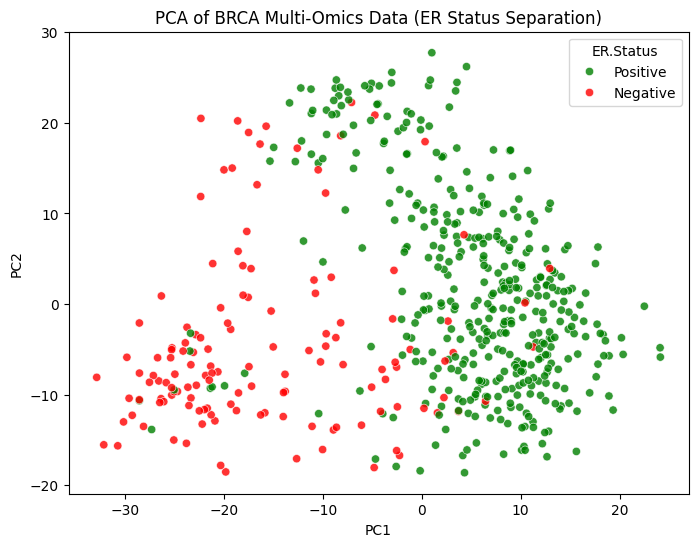

Explained variance ratio: [0.08278482 0.06188028]


In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA

# PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# dataframe for plotting
pca_df = pd.DataFrame({
    'PC1': X_pca[:, 0],
    'PC2': X_pca[:, 1],
    'ER.Status': ['Positive' if val == 1 else 'Negative' for val in y]
})

# Scatter plot
plt.figure(figsize=(8,6))
sns.scatterplot(data=pca_df, x='PC1', y='PC2', hue='ER.Status',
                palette={'Positive':'green','Negative':'red'}, alpha=0.8)
plt.title('PCA of BRCA Multi-Omics Data (ER Status Separation)')
plt.show()

# Explained variance
print("Explained variance ratio:", pca.explained_variance_ratio_)


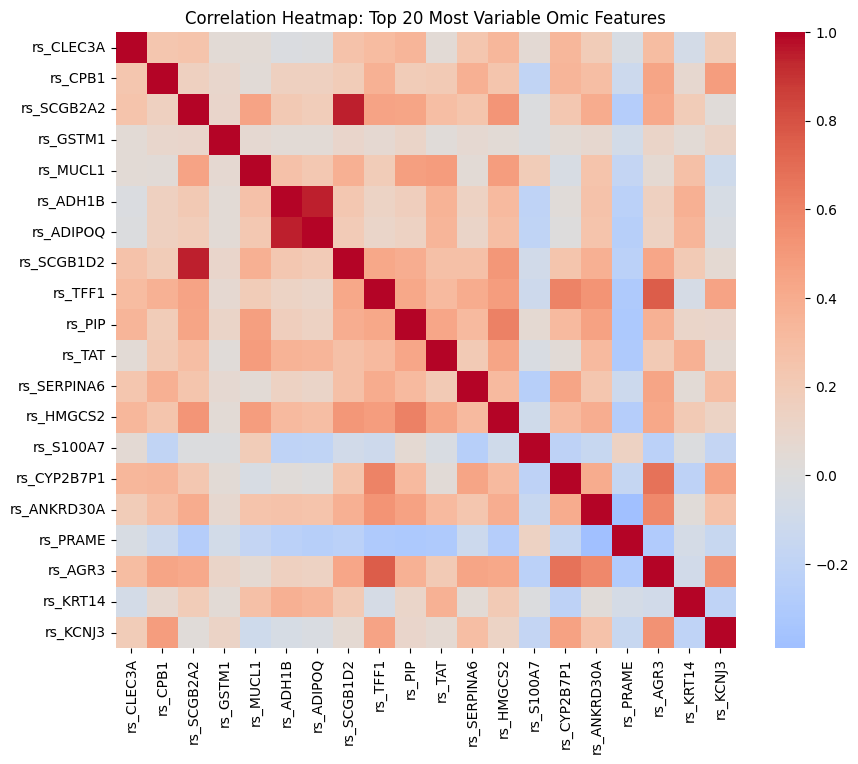

In [13]:
# Computing variance per feature
variances = X.var().sort_values(ascending=False)

# Selecting top 20 most variable features
top_features = variances.head(20).index

# Computing correlation matrix
corr = X[top_features].corr()

# Plotting heatmap
plt.figure(figsize=(10,8))
sns.heatmap(corr, cmap='coolwarm', center=0)
plt.title("Correlation Heatmap: Top 20 Most Variable Omic Features")
plt.show()


In [14]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Splitting data (80 / 20)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, stratify=y, random_state=42)

# Training baseline model
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, y_train)

# Evaluation
y_pred = lr.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print("Baseline Logistic Regression Accuracy:", round(acc, 3))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Baseline Logistic Regression Accuracy: 0.909

Classification Report:
               precision    recall  f1-score   support

           0       0.81      0.81      0.81        27
           1       0.94      0.94      0.94        83

    accuracy                           0.91       110
   macro avg       0.88      0.88      0.88       110
weighted avg       0.91      0.91      0.91       110



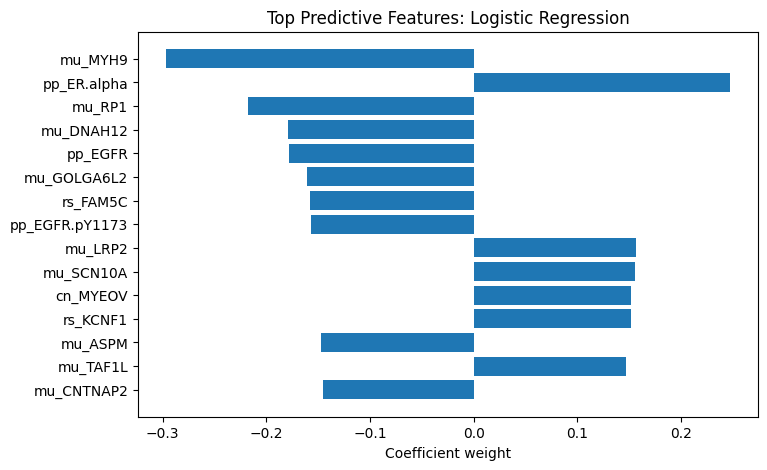

In [15]:
import numpy as np
coef = lr.coef_[0]
top_idx = np.argsort(np.abs(coef))[-15:][::-1]
top_features = X.columns[top_idx]
top_values = coef[top_idx]

import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))
plt.barh(top_features, top_values)
plt.gca().invert_yaxis()
plt.title("Top Predictive Features: Logistic Regression")
plt.xlabel("Coefficient weight")
plt.show()


In [17]:
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report


In [18]:
# Random Forest
rf = RandomForestClassifier(n_estimators=300, random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
rf_acc = accuracy_score(y_test, rf_pred)


In [19]:
# XGBoost
xgb = XGBClassifier(n_estimators=300, learning_rate=0.05, max_depth=4, random_state=42, use_label_encoder=False, eval_metric='logloss')
xgb.fit(X_train, y_train)
xgb_pred = xgb.predict(X_test)
xgb_acc = accuracy_score(y_test, xgb_pred)


/Users/zahinpeerzade/miniconda3/envs/brca_env/lib/python3.9/site-packages/xgboost/core.py:158: UserWarning: [15:25:29] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


In [20]:
# SVM
svm = SVC(kernel='rbf', C=1, gamma='scale')
svm.fit(X_train, y_train)
svm_pred = svm.predict(X_test)
svm_acc = accuracy_score(y_test, svm_pred)


In [21]:
print(f"Logistic Regression Accuracy: {acc:.3f}")
print(f"Random Forest Accuracy: {rf_acc:.3f}")
print(f"XGBoost Accuracy: {xgb_acc:.3f}")
print(f"SVM Accuracy: {svm_acc:.3f}")

Logistic Regression Accuracy: 0.909
Random Forest Accuracy: 0.891
XGBoost Accuracy: 0.918
SVM Accuracy: 0.900


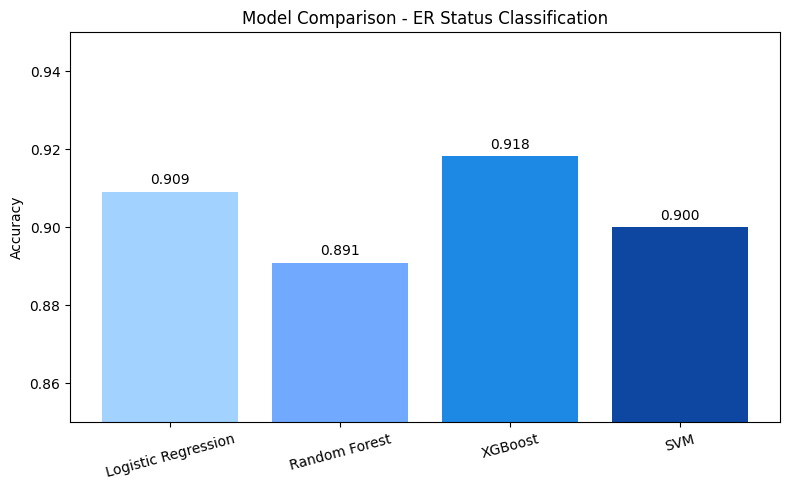

In [42]:
import matplotlib.pyplot as plt

models = ['Logistic Regression', 'Random Forest', 'XGBoost', 'SVM']
accuracies = [acc, rf_acc, xgb_acc, svm_acc]

colors = ['#a2d2ff', '#70a9ff', '#1e88e5', '#0d47a1']

plt.figure(figsize=(8,5))
plt.bar(models, accuracies, color=colors)
plt.ylabel('Accuracy')
plt.title('Model Comparison - ER Status Classification')
plt.ylim(0.85, 0.95)

for i, v in enumerate(accuracies):
    plt.text(i, v+0.002, f'{v:.3f}', ha='center', fontsize=10, color='black')

plt.xticks(rotation=15)
plt.tight_layout()
plt.show()


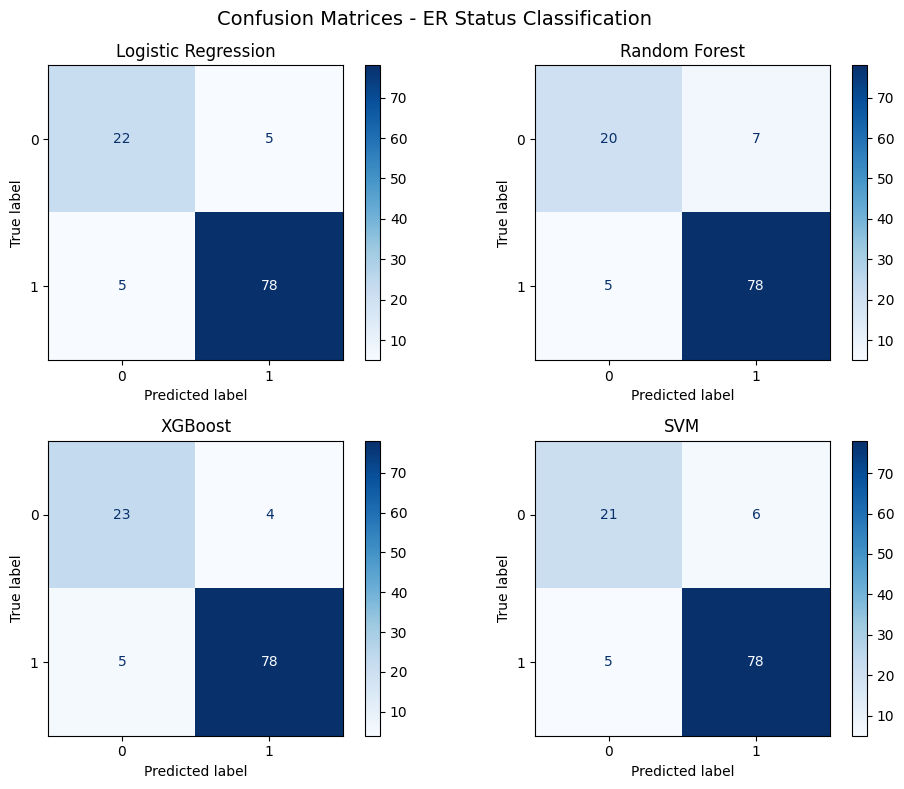

In [28]:
from sklearn.metrics import ConfusionMatrixDisplay

models_dict = {
    "Logistic Regression": (lr, y_pred),
    "Random Forest": (rf, rf_pred),
    "XGBoost": (xgb, xgb_pred),
    "SVM": (svm, svm_pred)
}

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.ravel()

for i, (name, (model, preds)) in enumerate(models_dict.items()):
    disp = ConfusionMatrixDisplay.from_predictions(y_test, preds, ax=axes[i], cmap='Blues')
    axes[i].set_title(name)

plt.suptitle("Confusion Matrices - ER Status Classification", fontsize=14)
plt.tight_layout()
plt.show()


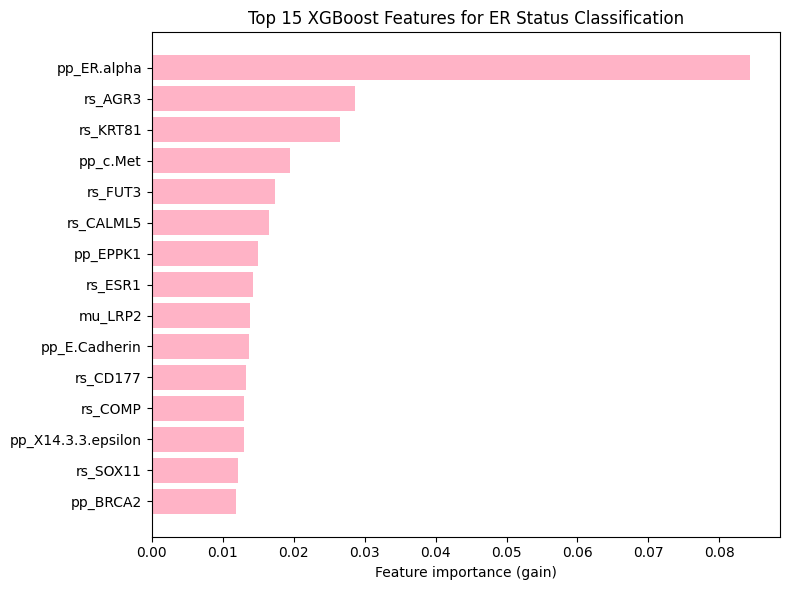

In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

importances = xgb_model.feature_importances_
indices = np.argsort(importances)[::-1][:15]
feature_names = X.columns[indices]
top_importances = importances[indices]

plt.figure(figsize=(8,6))
plt.barh(range(len(top_importances)), top_importances[::-1], color="#ffb3c6")
plt.yticks(range(len(top_importances)), feature_names[::-1])
plt.xlabel("Feature importance (gain)")
plt.title("Top 15 XGBoost Features for ER Status Classification")
plt.tight_layout()
plt.show()


In [34]:
import shap
import matplotlib.pyplot as plt

# Creating a TreeExplainer for trained XGBoost model
explainer = shap.TreeExplainer(xgb_model)

# SHAP values for the test set
shap_values = explainer.shap_values(X_test)

print("SHAP values shape:", shap_values.shape)


SHAP values shape: (110, 1937)


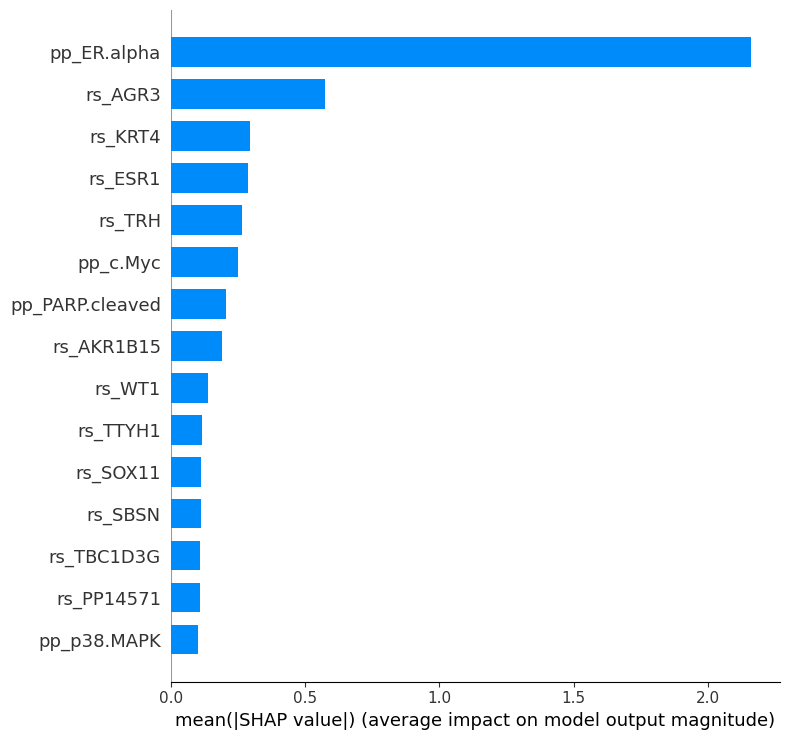

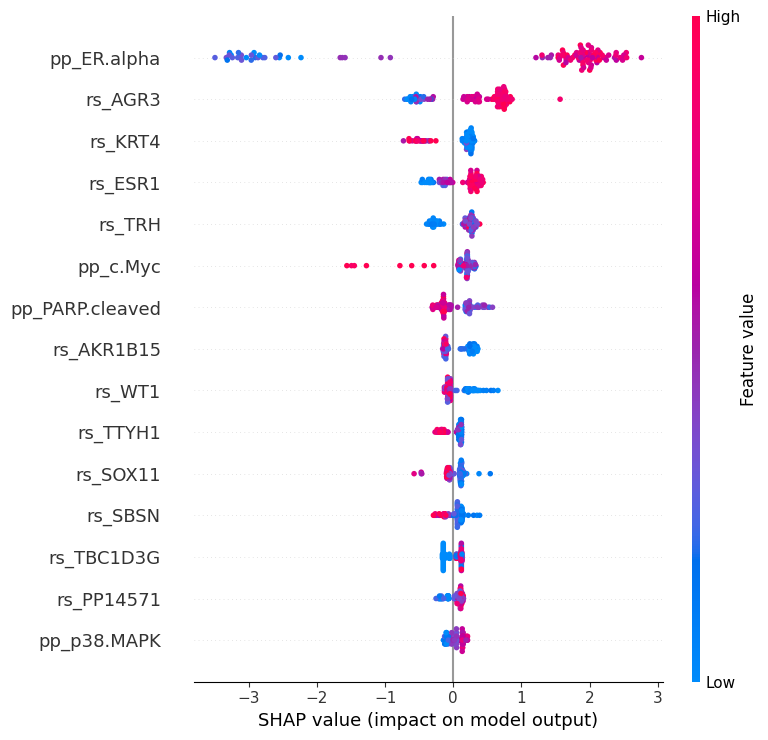

In [37]:
import pandas as pd

X_test_df = pd.DataFrame(X_test, columns=X.columns)

# Correctting SHAP plots with feature names
shap.summary_plot(
    shap_values, 
    features=X_test_df, 
    feature_names=X_test_df.columns, 
    plot_type="bar", 
    max_display=15
)

# Detailed plot with feature direction
shap.summary_plot(
    shap_values, 
    features=X_test_df, 
    feature_names=X_test_df.columns, 
    max_display=15
)


In [39]:
from sklearn.model_selection import cross_val_score, StratifiedKFold
import numpy as np

# 5-fold cross-validation strategy
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

models = {
    "Logistic Regression": lr,
    "Random Forest": rf,
    "XGBoost": xgb_model,
    "SVM": svm
}

for name, model in models.items():
    scores = cross_val_score(model, X_scaled, y, cv=cv, scoring='accuracy')
    print(f"{name}: Mean Accuracy = {scores.mean():.3f} (+/- {scores.std():.3f})")


Logistic Regression: Mean Accuracy = 0.907 (+/- 0.018)
Random Forest: Mean Accuracy = 0.927 (+/- 0.012)


/Users/zahinpeerzade/miniconda3/envs/brca_env/lib/python3.9/site-packages/xgboost/core.py:158: UserWarning: [17:01:48] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/Users/zahinpeerzade/miniconda3/envs/brca_env/lib/python3.9/site-packages/xgboost/core.py:158: UserWarning: [17:01:49] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/Users/zahinpeerzade/miniconda3/envs/brca_env/lib/python3.9/site-packages/xgboost/core.py:158: UserWarning: [17:01:50] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/Users/zahinpeerzade/miniconda3/envs/brca_env/lib/python3.9/site-packages/xgboost/core.py:158: UserWarning: [17:01:52] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parame

XGBoost: Mean Accuracy = 0.933 (+/- 0.016)
SVM: Mean Accuracy = 0.914 (+/- 0.022)


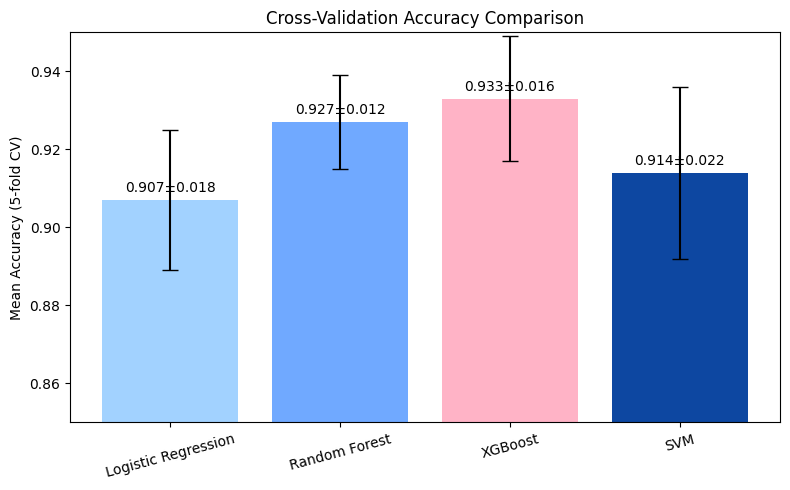

In [43]:
import matplotlib.pyplot as plt
import numpy as np

# Model names and accuracies 
models = ['Logistic Regression', 'Random Forest', 'XGBoost', 'SVM']
means = [0.907, 0.927, 0.933, 0.914]
stds = [0.018, 0.012, 0.016, 0.022]

plt.figure(figsize=(8,5))
plt.bar(models, means, yerr=stds, capsize=6, color=['#a2d2ff', '#70a9ff', '#ffb3c6', '#0d47a1'])
plt.ylabel('Mean Accuracy (5-fold CV)')
plt.title('Cross-Validation Accuracy Comparison')
plt.ylim(0.85, 0.95)

for i, v in enumerate(means):
    plt.text(i, v+0.002, f'{v:.3f}±{stds[i]:.3f}', ha='center', fontsize=10)

plt.xticks(rotation=15)
plt.tight_layout()
plt.show()
